<a href="https://colab.research.google.com/github/ashu433/Machine-Learning-Book-Practice-Q-A/blob/main/RNN_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import pandas as pd
import numpy as np
from datetime import datetime

In [66]:
def generate_time_series(batch_size,n_time_steps):
  freq1,freq2,offset1,offset2=np.random.rand(4,batch_size,1)
  time=np.linspace(0,1,n_time_steps)
  series=0.5*(np.sin((time-offset1)*(freq1*10+10)))
  series=series+0.2*(np.sin((time-offset2)*(freq2*20+20)))
  series=series+0.1*(np.random.rand(batch_size,n_time_steps))
  return series[...,np.newaxis].astype(np.float32)

In [67]:
n_steps=10
series=generate_time_series(10000,n_steps+1)

In [68]:
x_train,y_train=series[:7000,:n_steps],series[:7000,-1]
x_valid,y_valid=series[7000:9000,:n_steps],series[7000:9000,-1]
x_test,y_test=series[9000:,:n_steps],series[9000:,-1]

In [69]:
from sklearn.metrics import mean_squared_error
y_pred=x_valid[:,-1]
mse = mean_squared_error(y_valid, y_pred)
print("Naive baseline MSE:", mse)

Naive baseline MSE: 0.31694045662879944


In [70]:
import tensorflow as tf
from tensorflow import keras

In [71]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=(10, 1)),
    keras.layers.Dense(1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [72]:
model.compile(loss="mse",optimizer="adam")

In [73]:
model.fit(x_train,y_train,epochs=20,validation_data=(x_valid,y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5654 - val_loss: 0.3219
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2557 - val_loss: 0.1759
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1506 - val_loss: 0.1231
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1112 - val_loss: 0.1001
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0933 - val_loss: 0.0864
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0785 - val_loss: 0.0771
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0746 - val_loss: 0.0704
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0654 - val_loss: 0.0656
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0630 - val_loss: 0.0620
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0612 - val_loss: 0.0591
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0566 - val_loss: 0.0568
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [74]:
model_rnn=keras.models.Sequential([
    keras.layers.SimpleRNN(1,input_shape=[None,1])
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [75]:
model_rnn.compile(loss="mse",optimizer="adam")

In [76]:
model_rnn.fit(x_train,y_train,epochs=20,validation_data=(x_valid,y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.3148 - val_loss: 0.2713
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2747 - val_loss: 0.2323
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2332 - val_loss: 0.1987
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1982 - val_loss: 0.1726
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1701 - val_loss: 0.1554
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1534 - val_loss: 0.1458
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1455 - val_loss: 0.1417
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1427 - val_loss: 0.1403
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1374 - val_loss: 0.1399
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1397 - val_loss: 0.1399
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1421 - val_loss: 0.1400
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [77]:
model_deep_rnn=keras.models.Sequential([
    keras.layers.SimpleRNN(20,return_sequences=True,input_shape=[None,1]),
    keras.layers.SimpleRNN(20,return_sequences=True),
    keras.layers.SimpleRNN(1)
])

In [78]:
model_deep_rnn.compile(loss="mse",optimizer="adam")

In [79]:
model_deep_rnn.fit(x_train,y_train,epochs=20,validation_data=(x_valid,y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.1183 - val_loss: 0.0334
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0313 - val_loss: 0.0238
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0232 - val_loss: 0.0201
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0181 - val_loss: 0.0140
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0144 - val_loss: 0.0132
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0129 - val_loss: 0.0123
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0124 - val_loss: 0.0115
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0116 - val_loss: 0.0131
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0119 - val_loss: 0.0116
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0108 - val_loss: 0.0114
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0109 - val_loss: 0.0111
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms

In [80]:
model_lstm=keras.models.Sequential([
    keras.layers.LSTM(20,return_sequences=True,input_shape=[None,1]),
    keras.layers.LSTM(20),
    keras.layers.Dense(1)

])

In [81]:
model_lstm.compile(loss="mse",optimizer="adam")

In [82]:
model_lstm.fit(x_train,y_train,epochs=20,validation_data=(x_valid,y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.1197 - val_loss: 0.0406
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0421 - val_loss: 0.0369
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0377 - val_loss: 0.0309
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0319 - val_loss: 0.0242
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0233 - val_loss: 0.0186
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0180 - val_loss: 0.0168
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0166 - val_loss: 0.0154
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0162 - val_loss: 0.0155
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0154 - val_loss: 0.0145
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0148 - val_loss: 0.0142
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0140 - val_loss: 0.0135
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 

In [83]:
model_deep_rnn_output_dense=keras.models.Sequential([
    keras.layers.SimpleRNN(20,return_sequences=True,input_shape=[None,1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(1)
])

In [84]:
model_deep_rnn_output_dense.compile(loss="mse",optimizer="adam")

In [85]:
model_deep_rnn_output_dense.fit(x_train,y_train,epochs=20,validation_data=(x_valid,y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0722 - val_loss: 0.0196
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0179 - val_loss: 0.0150
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0150 - val_loss: 0.0153
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0135 - val_loss: 0.0127
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0123 - val_loss: 0.0122
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0124 - val_loss: 0.0118
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0113 - val_loss: 0.0110
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0115 - val_loss: 0.0113
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0109 - val_loss: 0.0124
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0109 - val_loss: 0.0129
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0109 - val_loss: 0.0100
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/ste

In [86]:
time_steps=10
series=generate_time_series(1,time_steps+10)

In [87]:
X_new,Y_new=series[:,:time_steps],series[:,time_steps:]

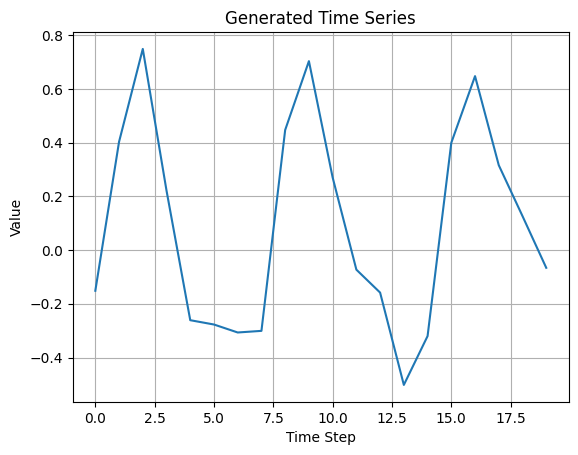

In [88]:
import matplotlib.pyplot as plt

plt.plot(series[0, :, 0])  # Take the first (and only) sample, all time steps, and remove the last dimension
plt.title("Generated Time Series")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [89]:
X=X_new

for step in range(10):
  y_predict=model_deep_rnn_output_dense.predict(X[:,step:])[:,np.newaxis,:]
  X=np.concatenate([X,y_predict],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [90]:
Y_pred=X[:,time_steps:]

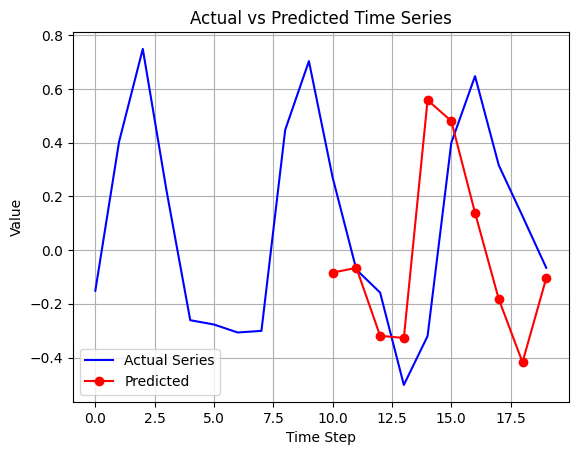

In [91]:
import matplotlib.pyplot as plt

time_steps = 10

# Plot original full series
plt.plot(series[0, :, 0], label="Actual Series", color='blue')

# Plot model's prediction (overlay from t=10 to t=19)
plt.plot(range(time_steps, time_steps + 10), Y_pred[0, :, 0], label="Predicted", color='red', marker='o')

plt.title("Actual vs Predicted Time Series")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


In [92]:
mse = np.mean((Y_pred - Y_new) ** 2)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.17641884


In [93]:
series = generate_time_series(10000, time_steps + 10)

In [94]:
X_train,Y_train=series[:7000,:time_steps],series[:7000,-10:,0]
X_valid,Y_valid=series[7000:9000,:time_steps],series[7000:9000,-10:,0]
X_test,Y_test=series[9000:,:time_steps],series[9000:,-10:,0]

In [95]:
model_deep_rnn_output_dense=keras.models.Sequential([
    keras.layers.SimpleRNN(20,return_sequences=True,input_shape=[None,1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(10)
])

In [96]:
model_deep_rnn_output_dense.compile(loss="mse",optimizer="adam")

In [97]:
model_deep_rnn_output_dense.fit(X_train,Y_train,epochs=20,validation_data=(X_valid,Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1375 - val_loss: 0.0817
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0792 - val_loss: 0.0695
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0685 - val_loss: 0.0622
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0588 - val_loss: 0.0524
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0509 - val_loss: 0.0474
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0438 - val_loss: 0.0392
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0394 - val_loss: 0.0367
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0370 - val_loss: 0.0353
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0338 - val_loss: 0.0327
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0325 - val_loss: 0.0321
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0317 - val_loss: 0.0311
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

In [98]:
Y=np.empty((10000,time_steps,10))

In [99]:
for step_ahead in range(1,10+1):
  Y[:,:,step_ahead-1]=series[:,step_ahead:step_ahead+time_steps,0]

In [100]:
Y_train = Y[:7000]
Y_valid = Y[7000:9000]
Y_test = Y[9000:]

In [101]:
model_updated=keras.models.Sequential([
    keras.layers.SimpleRNN(20,return_sequences=True,input_shape=[None,1]),
    keras.layers.SimpleRNN(20,return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

In [102]:
model_updated.compile(loss="mse",optimizer="adam")

In [103]:
model_updated.fit(X_train,Y_train,epochs=20,validation_data=(X_valid,Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.1297 - val_loss: 0.1011
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0994 - val_loss: 0.0991
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0968 - val_loss: 0.0959
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0934 - val_loss: 0.0905
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0880 - val_loss: 0.0863
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0842 - val_loss: 0.0833
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0814 - val_loss: 0.0811
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0795 - val_loss: 0.0811
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0786 - val_loss: 0.0796
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0767 - val_loss: 0.0778
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0761 - val_loss: 0.0770
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/s

In [104]:
from tensorflow import keras
import tensorflow as tf

def last_time_step_mse(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true[:, -1] - y_pred[:, -1]))

optimizer = keras.optimizers.Adam(learning_rate=0.01)

model_updated.compile(loss="mse", optimizer=optimizer, metrics=[last_time_step_mse])

In [105]:
model_updated.fit(X_train,Y_train,epochs=20,validation_data=(X_valid,Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - last_time_step_mse: 0.0620 - loss: 0.0883 - val_last_time_step_mse: 0.0334 - val_loss: 0.0735
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - last_time_step_mse: 0.0381 - loss: 0.0734 - val_last_time_step_mse: 0.0338 - val_loss: 0.0719
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - last_time_step_mse: 0.0356 - loss: 0.0718 - val_last_time_step_mse: 0.0342 - val_loss: 0.0715
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - last_time_step_mse: 0.0374 - loss: 0.0726 - val_last_time_step_mse: 0.0530 - val_loss: 0.0810
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - last_time_step_mse: 0.0379 - loss: 0.0716 - val_last_time_step_mse: 0.0414 - val_loss: 0.0734
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - last_time_step_mse: 0.0354 - loss: 0.0705 - val_last_time_step_mse: 0.0313 - val_loss: 0.0693
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - last_time_step_mse: 0.0346 - loss: 0.0698 - val_last_time

In [106]:
model_lstm = keras.models.Sequential([
keras.layers.LSTM(20, return_sequences=True, input_shape=[None, 1]),
keras.layers.LSTM(20, return_sequences=True),
keras.layers.LSTM(20, return_sequences=True),
keras.layers.TimeDistributed(keras.layers.Dense(10))
])

In [107]:
model_lstm.compile(loss="mse",optimizer="adam")

In [108]:
model_lstm.fit(X_train,Y_train,epochs=20,validation_data=(X_valid,Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.1372 - val_loss: 0.1092
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1031 - val_loss: 0.0908
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0851 - val_loss: 0.0807
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0773 - val_loss: 0.0756
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0732 - val_loss: 0.0738
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0716 - val_loss: 0.0720
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0702 - val_loss: 0.0711
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0691 - val_loss: 0.0706
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0684 - val_loss: 0.0699
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0678 - val_loss: 0.0691
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0669 - val_loss: 0.0691
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━

In [113]:
class layer_normalization(keras.layers.Layer):
  def __init__(self,units,activation="tanh",**kwargs):
    super().__init__(**kwargs)
    self.state_size=units
    self.output_size=units
    self.simple_rnn_layer=keras.layers.SimpleRNNCell(units,activation=None)
    self.layer_norm=keras.layers.LayerNormalization()
    self.activation=keras.activations.get(activation)

  def call(self,inputs,state):
    output,new_state=self.simple_rnn_layer(inputs,state)
    norm_output=self.activation(self.layer_norm(output))
    return norm_output,[norm_output]

In [114]:
model_layer_normalization=keras.models.Sequential([
    keras.layers.RNN(layer_normalization(20),return_sequences=True,input_shape=[None,1]),
    keras.layers.RNN(layer_normalization(20),return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'layer_normalization_8', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'layer_normalization_10', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked 

In [115]:
model_layer_normalization.compile(loss="mse",optimizer="adam")

In [116]:
model_layer_normalization.fit(X_train,Y_train,epochs=20,validation_data=(X_valid,Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.3022 - val_loss: 0.1206
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1159 - val_loss: 0.1085
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.1042 - val_loss: 0.1001
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0967 - val_loss: 0.0960
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0935 - val_loss: 0.0928
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0904 - val_loss: 0.0909
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0882 - val_loss: 0.0884
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0864 - val_loss: 0.0869
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0850 - val_loss: 0.0844
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0833 - val_loss: 0.0844
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0812 - val_loss: 0.0825
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 